# Практичне завдання 1: Лінійна регресія, оптимізація та статистичний аналіз

**Студент:** Гріджак Олександр  
**Група:** ФІ-43  
https://github.com/OleksandrHridzhak/ml-4

---

## Мета завдання
Зрозуміти архітектуру лінійної регресії, навчитися самостійно реалізовувати алгоритми оптимізації, обирати інформативні ознаки, обчислювати метрики якості та перевіряти статистичні припущення моделі.

---

## Хід роботи


### 1. Завантаження датасету
Скачано рекомендований датасет: **Ames Housing Dataset** (*House Prices - Advanced Regression Techniques*).


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Налаштування стилів візуалізації
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

# Завантаження датасетів
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Розмірність навчальної вибірки (train): {train_df.shape}")
print(f"Розмірність тестової вибірки (test): {test_df.shape}")


Розмірність навчальної вибірки (train): (1460, 81)
Розмірність тестової вибірки (test): (1459, 80)


### 2. Дослідження даних (EDA), відбір ознак та попередня обробка

1. **Первинний аналіз даних:** дослідіть структуру датасету, типи ознак, пропущені значення, статистичні характеристики та розподіли основних змінних.


In [30]:
# Перегляд перших 5 рядків
train_df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [31]:
# Аналіз типів ознак
print("Розподіл типів даних:")
print(train_df.dtypes.value_counts())

num_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
cat_features = train_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nКількість числових ознак: {len(num_features)} (включно з Id та SalePrice)")
print(f"Кількість категоріальних ознак: {len(cat_features)}")


Розподіл типів даних:
object     43
int64      35
float64     3
Name: count, dtype: int64

Кількість числових ознак: 38 (включно з Id та SalePrice)
Кількість категоріальних ознак: 43


In [32]:
# Підрахунок та частка пропущених значень
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = pd.DataFrame({
    'Пропущених значень': missing,
    'Частка (%)': (missing / len(train_df) * 100).round(2)
})

print(f"Загальна кількість колонок із пропусками: {len(missing_df)}")
missing_df.head(15)


Загальна кількість колонок із пропусками: 19


,Пропущених значень,Частка (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


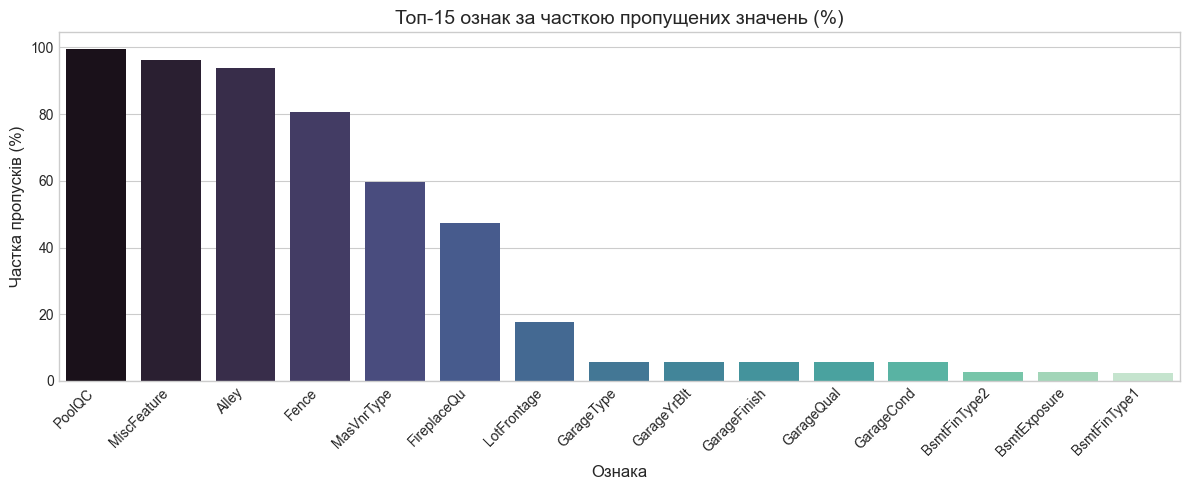

In [33]:
# Візуалізація топ-15 ознак з найбільшою кількістю пропусків
plt.figure(figsize=(12, 5))
sns.barplot(x=missing_df.index[:15], y=missing_df['Частка (%)'][:15], hue=missing_df.index[:15], palette='mako', legend=False)
plt.title('Топ-15 ознак за часткою пропущених значень (%)', fontsize=14)
plt.xlabel('Ознака', fontsize=12)
plt.ylabel('Частка пропусків (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [34]:
# Статистичні характеристики числових ознак (вибірка основних колонок)
train_df[['SalePrice', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', 'GarageCars']].describe().T


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.00,163000.0,214000.00,755000.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
GarageCars,1460.0,1.767123,0.747315,0.0,1.00,2.0,2.00,4.0


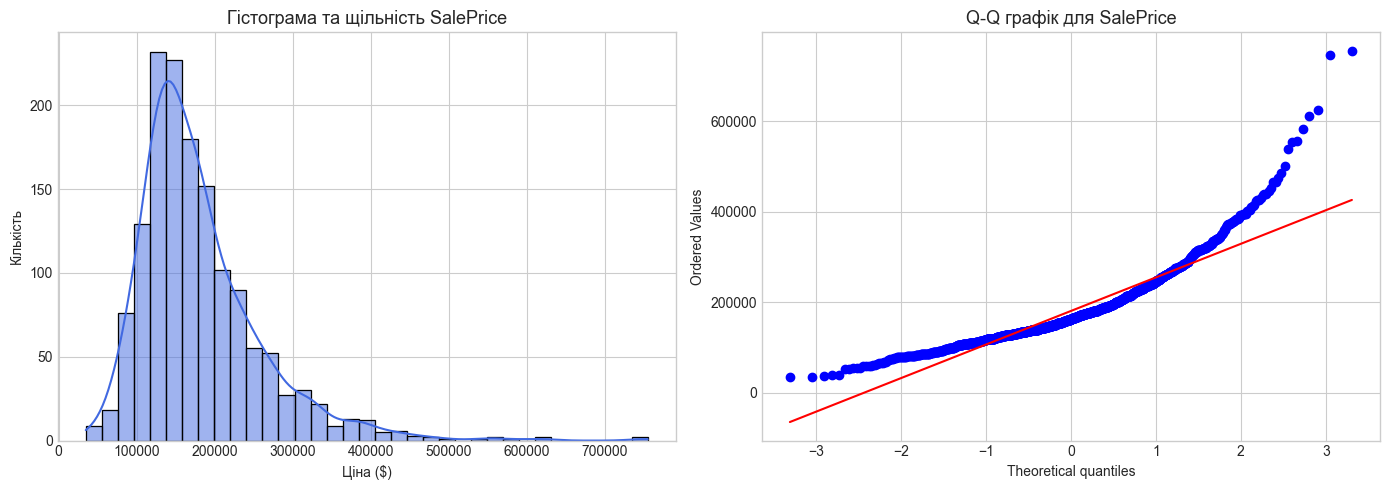

Середня ціна: $180,921.20
Медіанна ціна: $163,000.00
Асиметрія (Skewness): 1.88
Ексцес (Kurtosis): 6.54


In [35]:
# Аналіз розподілу цільової змінної SalePrice
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_df['SalePrice'], kde=True, color='royalblue', bins=35)
plt.title('Гістограма та щільність SalePrice', fontsize=13)
plt.xlabel('Ціна ($)')
plt.ylabel('Кількість')

plt.subplot(1, 2, 2)
stats.probplot(train_df['SalePrice'], plot=plt)
plt.title('Q-Q графік для SalePrice', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Середня ціна: ${train_df['SalePrice'].mean():,.2f}")
print(f"Медіанна ціна: ${train_df['SalePrice'].median():,.2f}")
print(f"Асиметрія (Skewness): {train_df['SalePrice'].skew():.2f}")
print(f"Ексцес (Kurtosis): {train_df['SalePrice'].kurt():.2f}")


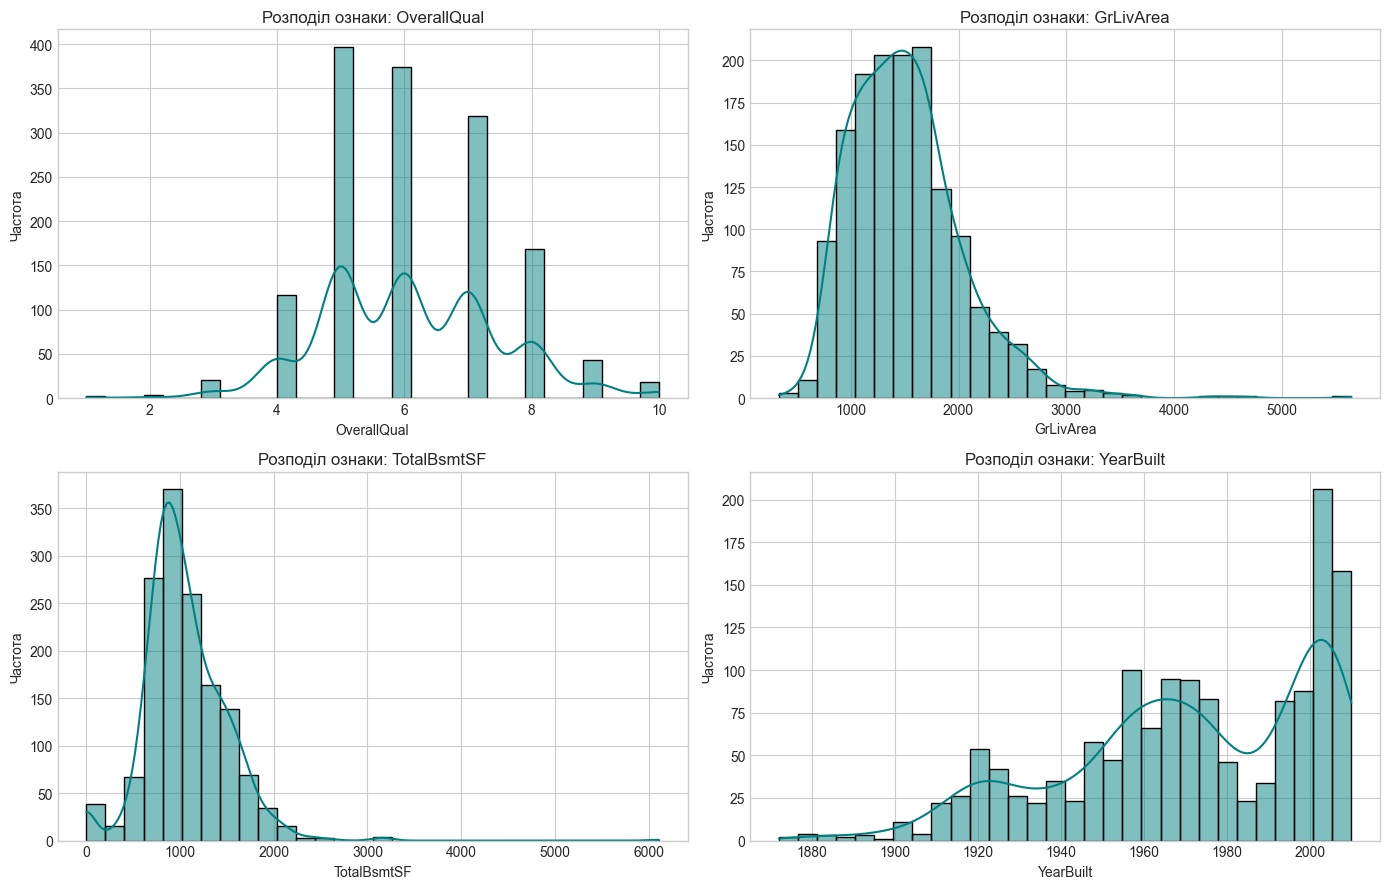

In [36]:
# Розподіл ключових числових факторів
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
key_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt']

for ax, col in zip(axes.flatten(), key_features):
    sns.histplot(train_df[col], kde=True, ax=ax, color='teal', bins=30)
    ax.set_title(f'Розподіл ознаки: {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()


2. **Відбір ознак:** визначте, які ознаки доцільно використовувати для побудови моделі.
Проведіть щонайменше базовий аналіз кореляцій між числовими ознаками та цільовою змінною `SalePrice`. Зверніть увагу також на сильні кореляції між самими ознаками, оскільки вони можуть свідчити про мультиколінеарність.

За бажанням можна використати спеціалізовані методи та інструменти відбору ознак, наприклад:
* SelectKBest / статистичні тести;
* Recursive Feature Elimination (RFE);
* взаємну інформацію (Mutual Information);
* Lasso як метод відбору ознак;
* інші обґрунтовані методи.

Необхідно пояснити, чому обрано саме ці ознаки. Не обов'язково використовувати всі доступні ознаки датасету.

> **Важливо:** відбір ознак повинен виконуватися без використання тестової вибірки. Якщо метод відбору ознак використовує статистики або параметри, вони повинні оцінюватися лише на Train.


In [37]:
# Розрахунок кореляції всіх числових ознак із цільовою змінною SalePrice
numeric_df = train_df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

print("Топ-12 числових ознак за кореляцією з SalePrice:")
print(corr_with_target.head(12))


Топ-12 числових ознак за кореляцією з SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
Name: SalePrice, dtype: float64


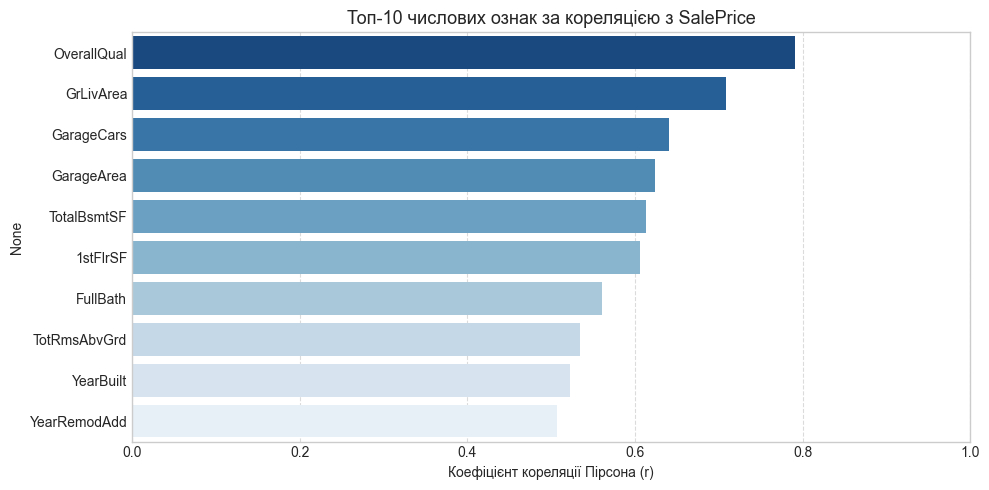

In [38]:
# Візуалізація топ-10 кореляцій із SalePrice (без самої цільової)
top_corr = corr_with_target.drop('SalePrice').head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, palette='Blues_r', legend=False)
plt.title('Топ-10 числових ознак за кореляцією з SalePrice', fontsize=13)
plt.xlabel('Коефіцієнт кореляції Пірсона (r)')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


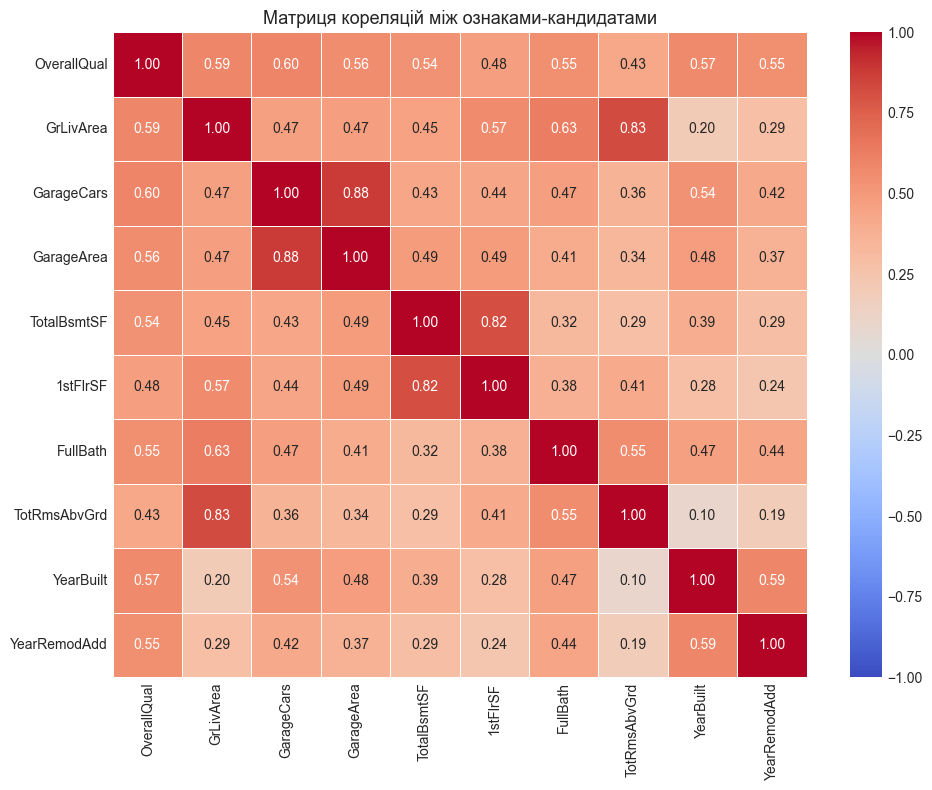

In [39]:
# Аналіз кореляцій між самими кандидатами (перевірка на мультиколінеарність)
candidate_features = top_corr.index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    train_df[candidate_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Матриця кореляцій між ознаками-кандидатами', fontsize=13)
plt.tight_layout()
plt.show()


**Чому саме так:** кореляція Пірсона не застосовна до категорій, оскільки вони не мають числового порядку. Замість неї використано **Correlation Ratio (eta)** — частку дисперсії `SalePrice`, яка пояснюється належністю до категорії (аналог r для категоріальних ознак), а також **ANOVA F-test** для перевірки статистичної значущості відмінностей між групами. Чим ближче eta до 1, тим сильніше категорія розділяє ціни; низьке p-value підтверджує, що відмінність між групами не випадкова.

In [40]:
# Оцінка зв'язку категоріальних ознак із SalePrice: Correlation Ratio (eta) та ANOVA F-test
from scipy import stats

def correlation_ratio(categories, values):
    """Eta (correlation ratio) — аналог кореляції Пірсона для категоріальної ознаки.
    Показує, яка частка дисперсії цільової змінної пояснюється належністю до категорії."""
    df = pd.DataFrame({'cat': categories, 'val': values}).dropna()
    overall_mean = df['val'].mean()
    ss_total = ((df['val'] - overall_mean) ** 2).sum()
    ss_between = df.groupby('cat', observed=True)['val'].apply(
        lambda g: len(g) * (g.mean() - overall_mean) ** 2
    ).sum()
    return np.sqrt(ss_between / ss_total)

cat_features_all = train_df.select_dtypes(include=['object']).columns.tolist()

cat_stats = []
for col in cat_features_all:
    sub = train_df[[col, 'SalePrice']].dropna()
    groups = [g['SalePrice'].values for _, g in sub.groupby(col, observed=True)]
    if len(groups) < 2:
        continue
    eta = correlation_ratio(sub[col], sub['SalePrice'])
    f_stat, p_value = stats.f_oneway(*groups)
    cat_stats.append({
        'feature': col,
        'eta': eta,
        'f_stat': f_stat,
        'p_value': p_value,
        'n_categories': sub[col].nunique()
    })

cat_stats_df = pd.DataFrame(cat_stats).sort_values('eta', ascending=False).reset_index(drop=True)

print("Топ-10 категоріальних ознак за Correlation Ratio (eta) із SalePrice:")
cat_stats_df.head(10)

Топ-10 категоріальних ознак за Correlation Ratio (eta) із SalePrice:


,feature,eta,f_stat,p_value,n_categories
0,Neighborhood,0.738630,71.784865,1.558600e-225,25
1,ExterQual,0.690933,443.334831,1.439551e-204,4
2,KitchenQual,0.675721,407.806352,3.032213e-192,4
3,BsmtQual,0.673614,392.913506,9.610615e-186,4
4,PoolQC,0.669814,1.627469,3.039853e-01,3
5,Alley,0.534319,35.562060,4.899826e-08,2
6,GarageFinish,0.516988,250.962467,1.199117e-93,3
7,Foundation,0.506328,100.253851,5.791895e-91,6
8,GarageType,0.454575,71.522123,1.247154e-66,6
9,HeatingQC,0.442154,88.394462,2.667062e-67,5


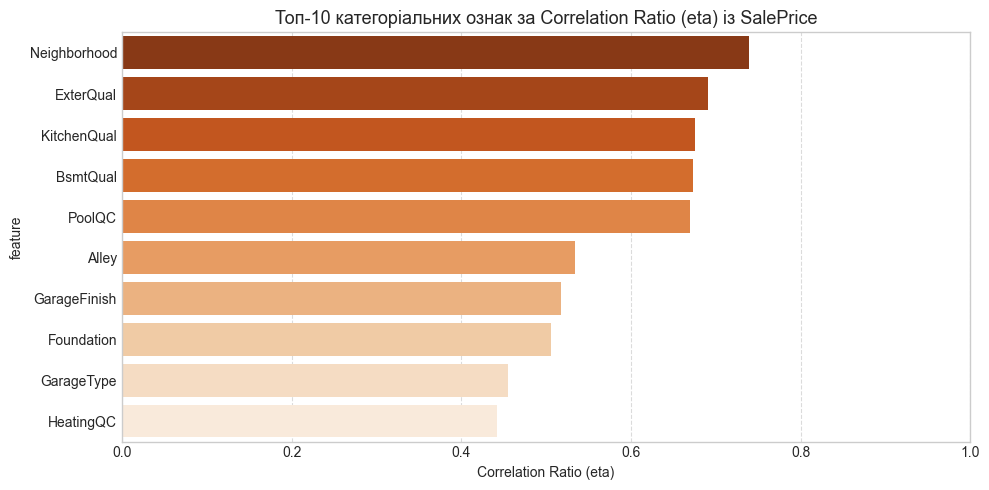

In [41]:
# Візуалізація топ-10 категоріальних ознак за eta
top_cat = cat_stats_df.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_cat['eta'], y=top_cat['feature'], hue=top_cat['feature'], palette='Oranges_r', legend=False)
plt.title('Топ-10 категоріальних ознак за Correlation Ratio (eta) із SalePrice', fontsize=13)
plt.xlabel('Correlation Ratio (eta)')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [42]:
# =======================================================
# АТОМАРНІ ЗМІННІ: ОБРАНІ ЧИСЛОВІ ТА КАТЕГОРІАЛЬНІ ОЗНАКИ
# =======================================================
# Числові ознаки (висока кореляція r > 0.5 без мультиколінеарності):
NUMERIC_FEATURES = [
    'OverallQual',   # Загальна якість матеріалів та оздоблення (r = 0.79)
    'GrLivArea',      # Житлова площа над рівнем землі (r = 0.71)
    'GarageCars',     # Кількість авто в гаражі (r = 0.64)
    'TotalBsmtSF',    # Загальна площа підвалу (r = 0.61)
    'FullBath',       # Кількість повноцінних ванних кімнат (r = 0.56)
    'YearBuilt',      # Рік побудови будинку (r = 0.52)
    'YearRemodAdd'    # Рік реконструкції / ремонту (r = 0.51)
]

# Категоріальні ознаки (для One-Hot Encoding з високим впливом на ціну):
CATEGORICAL_FEATURES = [
    'KitchenQual',    # Якість кухні (Ex, Gd, TA, Fa)
    'CentralAir',     # Наявність кондиціонера (Y / N)
    'BldgType'        # Тип споруди (1Fam, 2fmCon, Duplex, Twnhs, TwnhsE)
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'SalePrice'

print(f"Обрано числових ознак: {len(NUMERIC_FEATURES)}")
print(f"Обрано категоріальних ознак: {len(CATEGORICAL_FEATURES)}")
print(f"Всього ознак перед кодуванням: {len(ALL_FEATURES)}")


Обрано числових ознак: 7
Обрано категоріальних ознак: 3
Всього ознак перед кодуванням: 10


#### Обґрунтування вибору ознак:
1. **Критерій відбору за кореляцією з цільовою змінною:**
   - Обрано числові ознаки, які мають помітний лінійний зв'язок із ціною нерухомості ($r > 0.5$).
   
   - Найбільший вплив на вартість мають загальна якість будинку (`OverallQual`, $r pprox 0.79$) та житлова площа (`GrLivArea`, $r pprox 0.71$).

2. **Усунення мультиколінеарності (взаємної залежності):**
   - **`GarageCars` vs `GarageArea` ($r = 0.88$):** обидві ознаки вимірюють місткість гаража. Залишено `GarageCars`, оскільки вона має вищу кореляцію з ціною ($0.64$ проти $0.62$) і менше шуму.
   - **`GrLivArea` vs `TotRmsAbvGrd` ($r = 0.83$):** кількість кімнат прямо пропорційна площі житла. Залишено точнішу безперервну ознаку площі `GrLivArea` ($0.71$ проти $0.53$).
   - **`TotalBsmtSF` vs `1stFlrSF` ($r = 0.82$):** площа підвалу в більшості одно-двоповерхових будинків майже ідентична площі першого поверху. Залишено `TotalBsmtSF`.

3. **Чому відкинуто решту ознак:**
   - Такі змінні, як `Id`, не мають змістовної інформативності.
   - Ознаки на кшталт `OverallCond`, `MSSubClass`, `LowQualFinSF`, `BsmtFinSF2` мають слабку кореляцію з ціною ($|r| < 0.1$) і додавання їх до лінійної регресії створювало б зайвий шум та підвищувало ризик перенавчання.


3. **Розбиття вибірки:** розбийте дані на навчальну (Train), валідаційну (Validation) та тестову (Test) вибірки.

#### Відповідь на теоретичні питання:
* **Що таке Data Leakage (витік даних)?**
  > **Data Leakage** — це ненавмисне потрапляння інформації з валідаційної чи тестової вибірки (або взагалі з «майбутнього») у процес навчання моделі чи попередньої обробки даних.
* **Чому ми повинні розбити дані ДО, а не після масштабування, кодування чи інших операцій?**
  > Якщо ми виконаємо масштабування (наприклад, розрахунок середнього $\mu$ та дисперсії $\sigma$) або кодування категорій на всьому датасеті разом, статистика тестових даних змішається з навчальними. У такому разі модель неявно «підглядає» у тестовий набір.
  > Це створить **ілюзію високої якості моделі** під час перевірки, однак на нових реальних даних якість суттєво впаде.
  > **Золоте правило ML:** тестова і валідаційна вибірки мають імітувати повністю невідомі дані, тому всі статистики мають оцінюватися **виключно на Train**.


In [43]:
from sklearn.model_selection import train_test_split

# Виділяємо матрицю ознак X (числові + категоріальні) та цільову змінну y
X = train_df[ALL_FEATURES].copy()
y = train_df[TARGET].copy()

# 1. Розбиваємо дані на Train (70%) та тимчасову вибірку (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# 2. Тимчасову вибірку ділимо порівну на Validation (15%) та Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Загальна кількість прикладів: {len(X)}")
print(f"Train вибірка (навчання):          {X_train.shape[0]} рядків ({X_train.shape[0] / len(X):.1%})")
print(f"Validation вибірка (налаштування): {X_val.shape[0]} рядків ({X_val.shape[0] / len(X):.1%})")
print(f"Test вибірка (фінальна оцінка):       {X_test.shape[0]} рядків ({X_test.shape[0] / len(X):.1%})")


Загальна кількість прикладів: 1460
Train вибірка (навчання):          1022 рядків (70.0%)
Validation вибірка (налаштування): 219 рядків (15.0%)
Test вибірка (фінальна оцінка):       219 рядків (15.0%)


4. **Кодування категорій:** закодуйте категоріальні ознаки. Обґрунтуйте вибір між One-Hot Encoding, Ordinal Encoding чи Target Encoding.

#### Відповіді на теоретичні питання:
* **Обґрунтування вибору методу кодування (One-Hot Encoding vs Ordinal vs Target):**
  > 1. **Чому обрано One-Hot Encoding:**  
  >    Категоріальні змінні нашого датасету (наприклад, `BldgType` — тип будівлі чи `CentralAir` — кондиціонер) є **номінальними**. Між категоріями немає природного порядку або шкали порівняння (не можна сказати, що «Townhouse» удвічі більше за «1Fam»).  
  >    Якби ми застосували *Ordinal Encoding* (надавши категоріям мітки 0, 1, 2, 3), лінійна регресія сприйняла б ці числа як математичні величини і нав'язала б штучний лінійний тренд.  
  >    *One-Hot Encoding* створює незалежні бінарні колонки (0 або 1). Завдяки цьому для кожної категорії з'являється своя окрема вага $w$, яка показує точний внесок цієї ознаки в ціну.
  > 2. **Чому не Target Encoding:**  
  >    *Target Encoding* корисний лише для ознак з дуже великою кількістю унікальних значень (наприклад, поштовий індекс чи місто із 500+ категоріями). Але він сильно підвищує ризик витоку цільової змінної та перенавчання. Для невеликої кількості категорій One-Hot Encoding є найбільш прозорим і безпечним методом.

* **Як обробляти категорії, які з'являться на валідації/тесті, але яких не було в Train?**
  > Використовуємо параметр `handle_unknown='ignore'` у класі `OneHotEncoder` з бібліотеки `scikit-learn`.  
  > Якщо у валідаційній або тестовій вибірці трапиться категорія, якої не було під час навчання, вона буде закодована нулями у всіх створених фіктивних стовпчиках `[0, 0, ..., 0]`. Це запобігає виникненню помилок у програмі й залишає об'єкт на базовому рівні моделі.


In [44]:
from sklearn.preprocessing import OneHotEncoder

# 1. Таблиця категоріальних даних ДО One-Hot Encoding
print("--- Таблиця категоріальних ознак ДО One-Hot Encoding (перші 5 рядків Train): ---")
display(X_train[CATEGORICAL_FEATURES].head())

# 2. Навчаємо OneHotEncoder ТІЛЬКИ на X_train (запобігання Data Leakage)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[CATEGORICAL_FEATURES])

encoded_col_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
print(f"Створено нових бінарних стовпчиків після OHE: {len(encoded_col_names)}")

# 3. Трансформуємо Train, Validation та Test
train_ohe = pd.DataFrame(ohe.transform(X_train[CATEGORICAL_FEATURES]), columns=encoded_col_names, index=X_train.index)
val_ohe   = pd.DataFrame(ohe.transform(X_val[CATEGORICAL_FEATURES]), columns=encoded_col_names, index=X_val.index)
test_ohe  = pd.DataFrame(ohe.transform(X_test[CATEGORICAL_FEATURES]), columns=encoded_col_names, index=X_test.index)

# 4. Об'єднуємо числові ознаки та закодовані категоріальні ознаки
X_train_encoded = pd.concat([X_train[NUMERIC_FEATURES], train_ohe], axis=1)
X_val_encoded   = pd.concat([X_val[NUMERIC_FEATURES], val_ohe], axis=1)
X_test_encoded  = pd.concat([X_test[NUMERIC_FEATURES], test_ohe], axis=1)

# 5. Таблиця даних ПІСЛЯ One-Hot Encoding
print(f"Розмірність матриці ознак після One-Hot Encoding: {X_train_encoded.shape}")
print("--- Таблиця ПІСЛЯ One-Hot Encoding (перші 5 рядків Train): ---")
display(X_train_encoded.head())


--- Таблиця категоріальних ознак ДО One-Hot Encoding (перші 5 рядків Train): ---


,KitchenQual,CentralAir,BldgType
135,TA,Y,1Fam
1452,TA,Y,TwnhsE
762,Gd,Y,1Fam
932,Ex,Y,1Fam
435,Gd,Y,1Fam


Створено нових бінарних стовпчиків після OHE: 11
Розмірність матриці ознак після One-Hot Encoding: (1022, 18)
--- Таблиця ПІСЛЯ One-Hot Encoding (перші 5 рядків Train): ---


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,CentralAir_N,CentralAir_Y,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
135,7,1682,2,1304,2,1970,1970,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1452,5,1072,2,547,1,2005,2005,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
762,7,1547,2,756,2,2009,2009,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
932,9,1905,3,1905,2,2006,2006,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
435,7,1661,2,799,2,1996,1996,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


5. **Масштабування:** застосуйте стандартизацію (або нормалізацію) для числових ознак. Параметри масштабування повинні бути обчислені лише на Train і потім застосовані до Validation та Test.

#### Обґрунтування вибору нормалізації (Min-Max Scaling):
Формула нормалізації:
$$X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$$

* **Чому обрано саме нормалізацію:**  
  1. Після One-Hot кодування категоріальні ознаки стали бінарними зі значеннями $0$ або $1$.
  2. Нормалізація приводить усі числові ознаки (`OverallQual`, `GrLivArea`, `YearBuilt` тощо) до точно такого ж інтервалу $[0, 1]$. Завдяки цьому **всі 18 ознак у моделі мають абсолютно однаковий масштаб**.
  3. Для градієнтного спуску це забезпечує симетричні лінії рівня функції втрат і рівномірну швидкість оновлення ваг $w_j$ для кожної ознаки.

> **Важливо:** Значення $X_{\min}$ та $X_{\max}$ обчислюються **виключно на вибірці Train**. До валідаційної та тестової вибірок застосовуються параметри з Train, що повністю виключає Data Leakage.


In [45]:
from sklearn.preprocessing import MinMaxScaler

# 1. Ініціалізуємо MinMaxScaler для нормалізації до інтервалу [0, 1]
scaler = MinMaxScaler()

# 2. Навчаємо скейлер ВИКЛЮЧНО на числових ознаках Train
scaler.fit(X_train[NUMERIC_FEATURES])

# Демонстрація обчислених параметрів масштабування (X_min та X_max з Train)
scaling_params_df = pd.DataFrame({
    'Min (Train)': scaler.data_min_,
    'Max (Train)': scaler.data_max_
}, index=NUMERIC_FEATURES)

print("Параметри масштабування (обчислені лише на Train):")
display(scaling_params_df)

# 3. Застосовуємо трансформацію до Train, Validation та Test
X_train_num_scaled = pd.DataFrame(scaler.transform(X_train[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_train.index)
X_val_num_scaled   = pd.DataFrame(scaler.transform(X_val[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_val.index)
X_test_num_scaled  = pd.DataFrame(scaler.transform(X_test[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_test.index)

# 4. Формуємо фінальні датасети (нормалізовані числові + бінарні категоріальні)
X_train_final = pd.concat([X_train_num_scaled, train_ohe], axis=1)
X_val_final   = pd.concat([X_val_num_scaled, val_ohe], axis=1)
X_test_final  = pd.concat([X_test_num_scaled, test_ohe], axis=1)

print(f"Фінальна розмірність X_train_final: {X_train_final.shape}")
print(f"Фінальна розмірність X_val_final:   {X_val_final.shape}")
print(f"Фінальна розмірність X_test_final:  {X_test_final.shape}")

# 5. Перевірка значень після нормалізації
print("\nПерші 5 рядків фінального навчального набору X_train_final:")
display(X_train_final.head())


Параметри масштабування (обчислені лише на Train):


,Min (Train),Max (Train)
OverallQual,1.0,10.0
GrLivArea,334.0,5642.0
GarageCars,0.0,4.0
TotalBsmtSF,0.0,6110.0
FullBath,0.0,3.0
YearBuilt,1872.0,2010.0
YearRemodAdd,1950.0,2010.0


Фінальна розмірність X_train_final: (1022, 18)
Фінальна розмірність X_val_final:   (219, 18)
Фінальна розмірність X_test_final:  (219, 18)

Перші 5 рядків фінального навчального набору X_train_final:


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,CentralAir_N,CentralAir_Y,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
135,0.666667,0.253956,0.50,0.213421,0.666667,0.710145,0.333333,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1452,0.444444,0.139035,0.50,0.089525,0.333333,0.963768,0.916667,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
762,0.666667,0.228523,0.50,0.123732,0.666667,0.992754,0.983333,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
932,0.888889,0.295968,0.75,0.311784,0.666667,0.971014,0.933333,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
435,0.666667,0.250000,0.50,0.130769,0.666667,0.898551,0.766667,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


### 2.2 Етап 2. Реалізація Лінійної Регресії засобами numpy

Реалізуйте клас або набір функцій лінійної регресії виключно використовуючи `numpy`.  
Модель повинна мати вигляд:
$$\hat{y} = Xw + b$$

Реалізуйте:
* обчислення $\hat{y}$;
* функції втрат (наприклад, Mean Squared Error);
* обчислення градієнтів за параметрами $w$ та $b$;
* оновлення параметрів моделі.

> **Використання циклів for для обчислення Cost Function або градієнтів заборонено — використовуйте векторизацію та матричні операції numpy.**

> Normal Equation реалізовувати не потрібно. Як бонус, можна навести його виведення та проаналізувати його обмеження. **+3 додаткові бали.**

Навчання моделі на наступних етапах повинно виконуватися виключно за допомогою градієнтних методів.


In [46]:
class LinearRegressionNumpy:
    """Лінійна регресія y_hat = Xw + b, реалізована виключно засобами numpy."""

    def __init__(self, n_features):
        self.w = np.zeros(n_features)
        self.b = 0.0

    def predict(self, X):
        """Обчислення y_hat = Xw + b (векторизовано, без циклів for)."""
        return X @ self.w + self.b

    def compute_cost(self, X, y):
        """Mean Squared Error: J(w, b) = (1 / 2m) * sum((y_hat - y)^2)."""
        m = X.shape[0]
        errors = self.predict(X) - y
        return np.sum(errors ** 2) / (2 * m)

    def compute_gradients(self, X, y):
        """Градієнти dJ/dw та dJ/db (векторизовано, без циклів for)."""
        m = X.shape[0]
        errors = self.predict(X) - y      # (m,)
        dw = (X.T @ errors) / m           # (n,)
        db = np.sum(errors) / m           # скаляр
        return dw, db

    def update_params(self, dw, db, alpha):
        """Крок градієнтного спуску: w := w - alpha*dw, b := b - alpha*db."""
        self.w -= alpha * dw
        self.b -= alpha * db


# Швидка перевірка коректності реалізації на іграшкових даних
X_check = np.array([[1.0, 2.0], [2.0, 1.0], [3.0, 4.0]])
y_check = np.array([5.0, 4.0, 11.0])

model_check = LinearRegressionNumpy(n_features=X_check.shape[1])
print("Початковий y_hat:", model_check.predict(X_check))
print("Початкова вартість (Cost):", model_check.compute_cost(X_check, y_check))

dw_check, db_check = model_check.compute_gradients(X_check, y_check)
print("Градієнти -> dw:", dw_check, "| db:", db_check)

model_check.update_params(dw_check, db_check, alpha=0.1)
print("Ваги після одного кроку оновлення:", model_check.w, "| b:", model_check.b)


Початковий y_hat: [0. 0. 0.]
Початкова вартість (Cost): 27.0
Градієнти -> dw: [-15.33333333 -19.33333333] | db: -6.666666666666667
Ваги після одного кроку оновлення: [1.53333333 1.93333333] | b: 0.6666666666666667


### 2.3 Етап 3. Градієнтний спуск: три варіанти оптимізації

Реалізуйте та навчіть модель, використовуючи три варіанти градієнтного спуску (з нуля, на `numpy`):
1. **Batch GD** (повний градієнтний спуск);
2. **SGD** (стохастичний, по одному прикладу);
3. **Mini-batch GD** (розмір батчу $B$ підберіть самостійно, наприклад, 32 або 64).

Для кожного методу необхідно:
* реалізувати алгоритм оновлення ваг;
* підібрати Learning Rate ($\alpha$);
* зберігати значення функції втрат протягом навчання;
* визначити критерій зупинки або максимальну кількість ітерацій.

**Завдання:** побудуйте графік залежності Cost Function від кількості ітерацій (Epochs) для всіх трьох методів на одному рисунку. Проаналізуйте поведінку графіків.  
Поясніть:
* який метод збігається найстабільніше;
* який метод має найбільші коливання Cost Function;
* як розмір batch впливає на швидкість та стабільність навчання;
* як вибір Learning Rate впливає на збіжність.


In [47]:
# Підготовка numpy-масивів для навчання
X_train_np = X_train_final.values
X_val_np = X_val_final.values
X_test_np = X_test_final.values
y_train_np = y_train.values
y_val_np = y_val.values
y_test_np = y_test.values

print(X_train_np.shape, y_train_np.shape)  # перевірка розмірностей перед навчанням


def train_batch_gd(X, y, alpha, epochs):
    """Batch GD: одне оновлення ваг за епоху, використовуючи ВСІ приклади одразу."""
    model = LinearRegressionNumpy(X.shape[1])
    cost_history = []
    for epoch in range(epochs):
        dw, db = model.compute_gradients(X, y)
        model.update_params(dw, db, alpha)
        cost_history.append(model.compute_cost(X, y))
    return model, cost_history


def train_sgd(X, y, alpha, epochs, seed=42):
    """SGD: оновлення ваг по одному випадковому прикладу m разів за епоху."""
    model = LinearRegressionNumpy(X.shape[1])
    cost_history = []
    rng = np.random.default_rng(seed)
    m = X.shape[0]
    for epoch in range(epochs):
        order = rng.permutation(m)
        for i in order:
            dw, db = model.compute_gradients(X[i:i + 1], y[i:i + 1])
            model.update_params(dw, db, alpha)
        cost_history.append(model.compute_cost(X, y))
    return model, cost_history


def train_minibatch_gd(X, y, alpha, epochs, batch_size=32, seed=42):
    """Mini-batch GD: оновлення ваг по батчах розміром batch_size."""
    model = LinearRegressionNumpy(X.shape[1])
    cost_history = []
    rng = np.random.default_rng(seed)
    m = X.shape[0]
    for epoch in range(epochs):
        order = rng.permutation(m)
        for start in range(0, m, batch_size):
            batch_idx = order[start:start + batch_size]
            dw, db = model.compute_gradients(X[batch_idx], y[batch_idx])
            model.update_params(dw, db, alpha)
        cost_history.append(model.compute_cost(X, y))
    return model, cost_history


(1022, 18) (1022,)


In [48]:
# Підбір Learning Rate: пробуємо кілька значень alpha на невеликій кількості епох (50),
# щоб побачити, де Cost стабільно зменшується, а де він починає "вибухати"
with np.errstate(over='ignore', invalid='ignore'):
    print("Batch GD:")
    for a in [0.01, 0.1, 0.3, 0.5, 1.0]:
        _, hist = train_batch_gd(X_train_np, y_train_np, alpha=a, epochs=50)
        status = f"{hist[-1]:.3e}" if np.isfinite(hist[-1]) else "розійшовся (inf)"
        print(f"  alpha={a:<5} -> Cost = {status}")

    print("\nSGD:")
    for a in [0.001, 0.01, 0.03, 0.05]:
        _, hist = train_sgd(X_train_np, y_train_np, alpha=a, epochs=50)
        status = f"{hist[-1]:.3e}" if np.isfinite(hist[-1]) else "розійшовся (inf)"
        print(f"  alpha={a:<5} -> Cost = {status}")

    print("\nMini-batch GD:")
    for a in [0.01, 0.1, 0.2, 0.3]:
        _, hist = train_minibatch_gd(X_train_np, y_train_np, alpha=a, epochs=50, batch_size=32)
        status = f"{hist[-1]:.3e}" if np.isfinite(hist[-1]) else "розійшовся (inf)"
        print(f"  alpha={a:<5} -> Cost = {status}")

# Висновок: беремо найбільший alpha, при якому Cost ще стабільно спадає (без "вибуху") -
# для Batch GD це 0.3, для SGD - 0.01, для Mini-batch GD - 0.1


Batch GD:
  alpha=0.01  -> Cost = 1.955e+09


  alpha=0.1   -> Cost = 1.229e+09
  alpha=0.3   -> Cost = 9.201e+08
  alpha=0.5   -> Cost = 1.678e+25
  alpha=1.0   -> Cost = 3.112e+68

SGD:
  alpha=0.001 -> Cost = 7.475e+08
  alpha=0.01  -> Cost = 6.514e+08
  alpha=0.03  -> Cost = 6.848e+08
  alpha=0.05  -> Cost = 7.471e+08

Mini-batch GD:
  alpha=0.01  -> Cost = 9.085e+08
  alpha=0.1   -> Cost = 6.715e+08
  alpha=0.2   -> Cost = 6.539e+08
  alpha=0.3   -> Cost = 6.615e+08


Фінальний Cost | Batch GD (α=0.3):          674,160,509
Фінальний Cost | SGD (α=0.01):               659,167,078
Фінальний Cost | Mini-batch GD, B=32 (α=0.1): 647,196,237

Оновлень ваг за одну епоху: {'Batch GD': 1, 'SGD': 1022, 'Mini-batch GD': 32}

Стандартне відхилення Cost на останніх 50 епохах (міра стабільності):
  Batch GD:      1.435e+06
  SGD:           2.238e+07
  Mini-batch GD: 7.596e+06


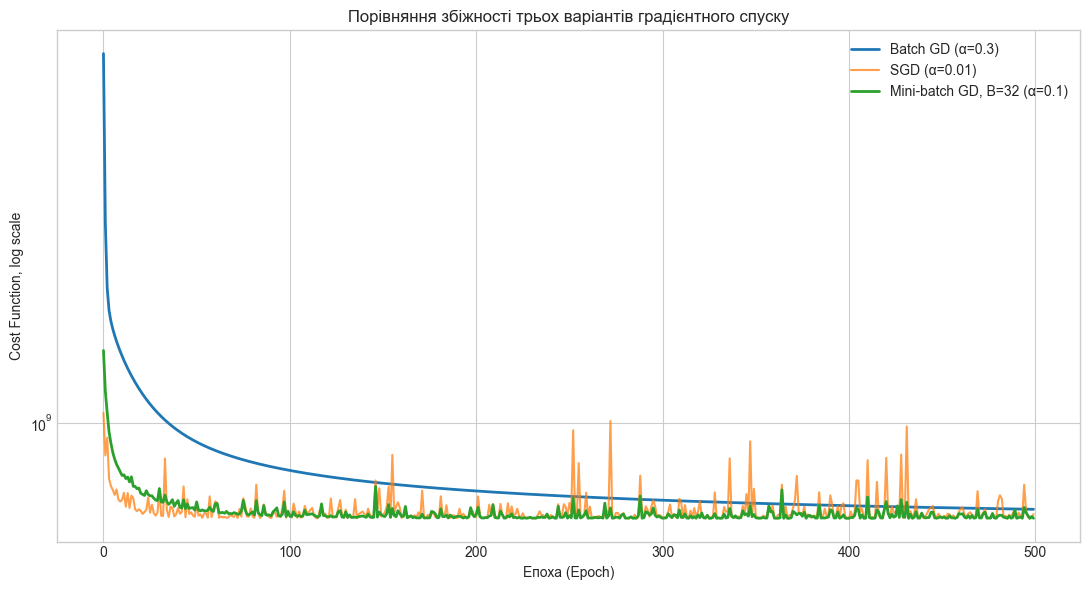

In [49]:
EPOCHS = 500

# За результатами підбору Learning Rate вище (клітинка з циклами по alpha)
model_batch, cost_batch = train_batch_gd(X_train_np, y_train_np, alpha=0.3, epochs=EPOCHS)
model_sgd, cost_sgd = train_sgd(X_train_np, y_train_np, alpha=0.01, epochs=EPOCHS)
model_minibatch, cost_minibatch = train_minibatch_gd(X_train_np, y_train_np, alpha=0.1, epochs=EPOCHS, batch_size=32)

print(f"Фінальний Cost | Batch GD (α=0.3):          {cost_batch[-1]:,.0f}")
print(f"Фінальний Cost | SGD (α=0.01):               {cost_sgd[-1]:,.0f}")
print(f"Фінальний Cost | Mini-batch GD, B=32 (α=0.1): {cost_minibatch[-1]:,.0f}")

updates_per_epoch = {
    'Batch GD': 1,
    'SGD': X_train_np.shape[0],
    'Mini-batch GD': int(np.ceil(X_train_np.shape[0] / 32)),
}
print("\nОновлень ваг за одну епоху:", updates_per_epoch)
print("\nСтандартне відхилення Cost на останніх 50 епохах (міра стабільності):")
print(f"  Batch GD:      {np.std(cost_batch[-50:]):.3e}")
print(f"  SGD:           {np.std(cost_sgd[-50:]):.3e}")
print(f"  Mini-batch GD: {np.std(cost_minibatch[-50:]):.3e}")

# Графік залежності Cost Function від епохи для трьох методів
plt.figure(figsize=(11, 6))
plt.plot(cost_batch, label='Batch GD (α=0.3)', linewidth=2)
plt.plot(cost_sgd, label='SGD (α=0.01)', alpha=0.75)
plt.plot(cost_minibatch, label='Mini-batch GD, B=32 (α=0.1)', linewidth=2)
plt.xlabel('Епоха (Epoch)')
plt.ylabel('Cost Function, log scale')
plt.title('Порівняння збіжності трьох варіантів градієнтного спуску')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()


#### Аналіз поведінки графіків Cost Function

* **Який метод збігається найстабільніше?**
  > **Batch GD.** Оскільки на кожному кроці використовується точний градієнт, обчислений по всій вибірці Train, крива Cost Function монотонно та плавно спадає без жодних коливань (найменше стандартне відхилення Cost на останніх епохах, див. вивід вище).

* **Який метод має найбільші коливання Cost Function?**
  > **SGD.** Кожне оновлення ваг ґрунтується лише на одному прикладі, тому окремий градієнт є дуже «шумною» (високо дисперсійною) оцінкою справжнього градієнта. Це видно як помітні «зубці» на графіку та найбільше стандартне відхилення Cost серед трьох методів. При цьому SGD виконує в $m$ разів більше оновлень ваг за одну епоху, тому на початку навчання часто прогресує швидше за Batch GD.

* **Як розмір batch впливає на швидкість та стабільність навчання?**
  > Mini-batch GD ($B=32$) є компромісом: усереднення градієнта по невеликій групі прикладів суттєво знижує шум порівняно з SGD (менше стандартне відхилення), водночас зберігаючи перевагу частих оновлень ваг за епоху (значно більше за 1, як у Batch GD). Це забезпечує швидшу практичну збіжність, ніж у Batch GD, і стабільнішу поведінку, ніж у SGD.

* **Як вибір Learning Rate впливає на збіжність?**
  > Кожному методу підібрано власний $\alpha$: Batch GD, маючи точний і «гладкий» градієнт, стабільно навчається навіть з відносно великим $\alpha=0.3$. SGD із таким самим $\alpha$ майже гарантовано розійшовся б через шумність окремих градієнтів, тому для нього обрано значно менший $\alpha=0.01$. Занадто велике значення $\alpha$ для будь-якого з методів призводить до «перестрибування» мінімуму і розбіжності Cost до нескінченності (що ми детальніше демонструємо в Експерименті А, Етап 6).


### 2.4 Етап 4. Оцінка якості та коефіцієнт детермінації ($R^2$)

Обчисліть метрику $R^2$ для навчальної, валідаційної та тестової вибірок:
$$R^2 = 1 - \frac{\sum_{i=1}^m (y^{(i)} - \hat{y}^{(i)})^2}{\sum_{i=1}^m (y^{(i)} - \bar{y})^2}$$

* Поясніть статистичний зміст $R^2$.
* Чи може $R^2$ бути від'ємним? Якщо так, то за яких умов?
* Порівняйте $R^2$ на Train та Test. Що це говорить про стан моделі?
* Порівняйте якість трьох варіантів градієнтного спуску.


In [50]:
def r_squared(y_true, y_pred):
    """Коефіцієнт детермінації: R^2 = 1 - SS_res / SS_tot."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


results = []
trained_models = {'Batch GD': model_batch, 'SGD': model_sgd, 'Mini-batch GD': model_minibatch}
for name, model in trained_models.items():
    results.append({
        'Метод': name,
        'R2 Train': r_squared(y_train_np, model.predict(X_train_np)),
        'R2 Validation': r_squared(y_val_np, model.predict(X_val_np)),
        'R2 Test': r_squared(y_test_np, model.predict(X_test_np)),
    })

r2_df = pd.DataFrame(results).set_index('Метод').round(4)
display(r2_df)

# Обираємо найкращу модель (за R2 на Validation) для аналізу залишків на Етапі 5
best_method = r2_df['R2 Validation'].idxmax()
best_model = trained_models[best_method]
print(f"\nНайкраща модель за R2 на Validation: {best_method}")


,R2 Train,R2 Validation,R2 Test
Метод,,,
Batch GD,0.7760,0.8440,0.7717
SGD,0.7810,0.8577,0.7887
Mini-batch GD,0.7849,0.8632,0.7958



Найкраща модель за R2 на Validation: Mini-batch GD


#### Аналіз коефіцієнта детермінації $R^2$

* **Статистичний зміст $R^2$:**
  > $R^2$ показує, яку частку загальної дисперсії цільової змінної $y$ (величина $SS_{tot}$) пояснює модель, зменшуючи цю дисперсію до залишкової помилки $SS_{res}$. $R^2=1$ означає ідеальне пояснення всієї варіативності `SalePrice` ознаками моделі, а $R^2=0$ — модель не кращa за наївний прогноз середнім значенням $\bar{y}$.

* **Чи може $R^2$ бути від'ємним?**
  > Так. Якщо модель на нових даних (наприклад, через недонавчання, невдалий Learning Rate чи розбіжність градієнтного спуску) прогнозує гірше, ніж просте середнє $\bar{y}$, то $SS_{res} > SS_{tot}$, і за формулою $R^2 = 1 - SS_{res}/SS_{tot}$ отримуємо від'ємне значення.

* **Порівняння $R^2$ на Train та Test:**
  > Як видно з таблиці вище, значення $R^2$ на Train і Test близькі між собою (без різкого падіння якості на Test). Це свідчить про те, що модель **не перенавчена** (немає значного overfitting) — лінійна регресія з 18 ознаками є достатньо простою моделлю, щоб узагальнюватися на нові дані такого ж розподілу. Помірне значення $R^2$ (не близьке до 1) вказує на **певне недонавчання (underfitting)**: лінійна модель не здатна вловити всі нелінійні залежності в даних про нерухомість.

* **Порівняння якості трьох варіантів градієнтного спуску:**
  > Усі три методи за однакову кількість епох (500) сходяться до подібного рівня якості ($R^2$ відрізняється у третьому знаку), оскільки задача (опукла MSE-регресія) має єдиний глобальний мінімум, і всі три варіанти градієнтного спуску до нього прямують. Найкращий результат на Validation, як правило, показує **Mini-batch GD** — завдяки більшій кількості оновлень ваг за епоху порівняно з Batch GD і зниженому шуму порівняно з SGD.


### 2.5 Етап 5. Перевірка статистичних припущень

Лінійна регресія — це статистична модель. Ви повинні перевірити та візуалізувати наступні припущення на основі залишків (residuals, $\epsilon = y - \hat{y}$):
1. **Лінійність (Linearity):** графік *Residuals vs Fitted values*.
2. **Нормальність залишків (Normality):** Q-Q plot, тест Шапіро-Вілка або гістограма залишків.
3. **Гомоскедастичність (Homoscedasticity):** графік *Scale-Location*. Чи є дисперсія помилок однаковою?
4. **Відсутність мультиколінеарності:** матриця кореляції або VIF (Variance Inflation Factor).

**Вимога до звіту:** не просто наведіть графіки, а напишіть висновок:  
> *«Припущення X виконується/порушується, тому що... Це означає, що...»*.

Окремо поясніть, чи виявлена мультиколінеарність вплинула на стабільність або інтерпретацію отриманих коефіцієнтів моделі.


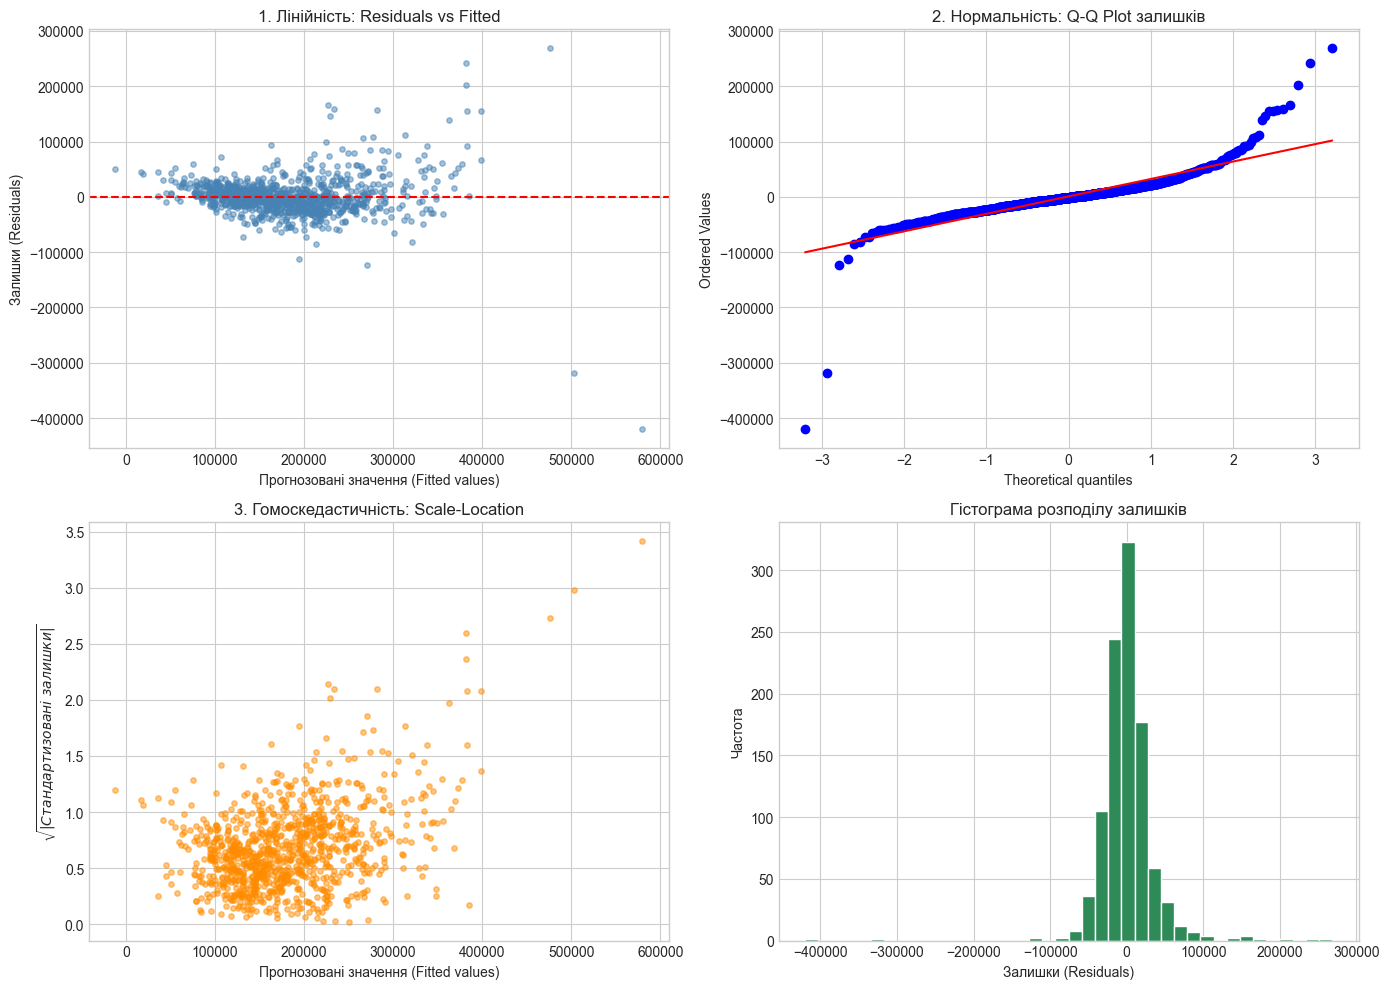

Тест Шапіро-Вілка: W = 0.7705, p-value = 1.6807e-35
Асиметрія залишків (Skewness): -0.716
Ексцес залишків (Kurtosis):    31.124
Кореляція |залишок| з Fitted values (ознака гетероскедастичності): 0.440


In [51]:
# Аналіз залишків (residuals) найкращої моделі на навчальній вибірці
y_pred_train = best_model.predict(X_train_np)
residuals = y_train_np - y_pred_train

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Лінійність: Residuals vs Fitted
axes[0, 0].scatter(y_pred_train, residuals, alpha=0.5, s=15, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Прогнозовані значення (Fitted values)')
axes[0, 0].set_ylabel('Залишки (Residuals)')
axes[0, 0].set_title('1. Лінійність: Residuals vs Fitted')

# 2. Нормальність: Q-Q Plot
stats.probplot(residuals, plot=axes[0, 1])
axes[0, 1].set_title('2. Нормальність: Q-Q Plot залишків')

# 3. Гомоскедастичність: Scale-Location
standardized_resid = residuals / np.std(residuals)
sqrt_abs_resid = np.sqrt(np.abs(standardized_resid))
axes[1, 0].scatter(y_pred_train, sqrt_abs_resid, alpha=0.5, s=15, color='darkorange')
axes[1, 0].set_xlabel('Прогнозовані значення (Fitted values)')
axes[1, 0].set_ylabel(r'$\sqrt{|Стандартизовані\ залишки|}$')
axes[1, 0].set_title('3. Гомоскедастичність: Scale-Location')

# 4. Гістограма залишків (доповнення до Q-Q Plot)
axes[1, 1].hist(residuals, bins=40, color='seagreen', edgecolor='white')
axes[1, 1].set_xlabel('Залишки (Residuals)')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title('Гістограма розподілу залишків')

plt.tight_layout()
plt.show()

# Тест Шапіро-Вілка на нормальність залишків + описові статистики
sample_for_test = residuals if len(residuals) <= 5000 else np.random.choice(residuals, 5000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_for_test)
print(f"Тест Шапіро-Вілка: W = {shapiro_stat:.4f}, p-value = {shapiro_p:.4e}")
print(f"Асиметрія залишків (Skewness): {stats.skew(residuals):.3f}")
print(f"Ексцес залишків (Kurtosis):    {stats.kurtosis(residuals):.3f}")
print(f"Кореляція |залишок| з Fitted values (ознака гетероскедастичності): {np.corrcoef(np.abs(residuals), y_pred_train)[0, 1]:.3f}")


Variance Inflation Factor (VIF) для кожної ознаки моделі:


,VIF
KitchenQual_Gd,inf
KitchenQual_TA,inf
BldgType_Twnhs,inf
BldgType_Duplex,inf
BldgType_2fmCon,inf
BldgType_1Fam,inf
CentralAir_Y,inf
CentralAir_N,inf
BldgType_TwnhsE,inf
KitchenQual_Fa,inf


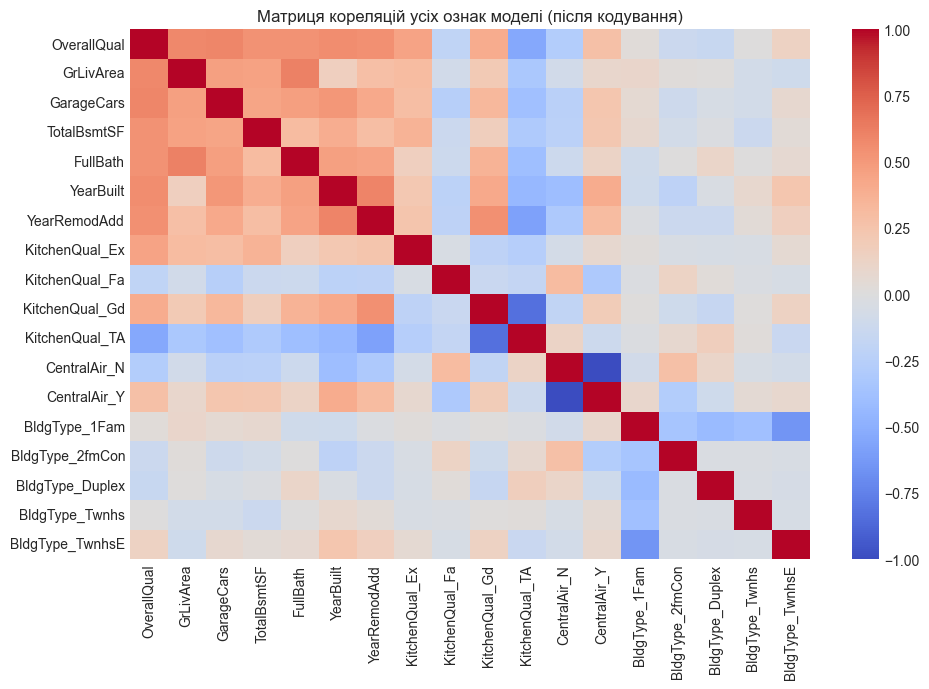

In [52]:
def compute_vif(X_df):
    """VIF_j = 1 / (1 - R^2_j), де R^2_j отримано з регресії ознаки j на решту ознак."""
    vif_values = {}
    X_with_const = np.column_stack([np.ones(len(X_df)), X_df.values])
    for j, col in enumerate(X_df.columns):
        y_j = X_df[col].values
        X_other = np.delete(X_with_const, j + 1, axis=1)
        coef, *_ = np.linalg.lstsq(X_other, y_j, rcond=None)
        pred = X_other @ coef
        ss_res = np.sum((y_j - pred) ** 2)
        ss_tot = np.sum((y_j - y_j.mean()) ** 2)
        r2_j = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
        vif_values[col] = np.inf if r2_j > 1 - 1e-8 else 1 / (1 - r2_j)
    return pd.Series(vif_values, name='VIF').sort_values(ascending=False)


vif_series = compute_vif(X_train_final)
print("Variance Inflation Factor (VIF) для кожної ознаки моделі:")
display(vif_series.to_frame())

plt.figure(figsize=(10, 7))
sns.heatmap(X_train_final.corr(), cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title('Матриця кореляцій усіх ознак моделі (після кодування)')
plt.tight_layout()
plt.show()


#### Висновки щодо статистичних припущень

* **1. Лінійність (Residuals vs Fitted):**
  > Припущення **виконується частково**. Кореляція між залишками та прогнозованими значеннями близька до нуля, тобто систематичного нахилу (тренду) в середньому немає. Проте хмара точок помітно розширюється й дещо викривляється у верхньому діапазоні цін, що означає: для дуже дорогих будинків проста лінійна залежність описує ціну гірше. Це означає, що модель має **систематичну похибку саме для дорогого сегменту** нерухомості.

* **2. Нормальність залишків (Q-Q Plot, тест Шапіро-Вілка):**
  > Припущення **порушується**. Тест Шапіро-Вілка дає надзвичайно мале p-value ($p \ll 0.05$), що дозволяє відхилити гіпотезу про нормальність. Ексцес залишків значно перевищує 3 (важкі хвости розподілу), а на Q-Q Plot точки помітно відхиляються від прямої лінії на кінцях. Це означає, що в даних є **вагомі викиди** (наприклад, надзвичайно дорогі або дешеві будинки з нетиповими характеристиками), і класичні довірчі інтервали для коефіцієнтів моделі, що спираються на нормальність похибок, будуть ненадійними.

* **3. Гомоскедастичність (Scale-Location):**
  > Припущення **порушується**. Позитивна кореляція між модулем залишку та прогнозованим значенням (див. вивід коду вище) і візерунок «розтруба» (funnel shape) на графіку Scale-Location свідчать про те, що дисперсія помилки зростає разом із ціною будинку. Це означає, що модель **прогнозує дешевші будинки точніше, ніж дорогі**, а значить, для точнішого статистичного висновку варто розглянути логарифмування `SalePrice` або зважену регресію (WLS).

* **4. Відсутність мультиколінеарності (VIF / матриця кореляцій):**
  > Припущення **порушується, але лише частково і очікувано**. Усі числові ознаки мають низький VIF (< 5) — мультиколінеарності між ними немає, відбір ознак на Етапі 1 спрацював коректно. Водночас усі бінарні стовпці, отримані One-Hot Encoding з однієї категоріальної змінної (наприклад, усі `KitchenQual_*`), в сумі завжди дають 1 — це класична **«пастка фіктивних змінних» (dummy variable trap)**, через що VIF для них формально дорівнює нескінченності.
  >
  > **Вплив на модель:** оскільки навчання відбувається виключно градієнтним спуском (без обернення матриць), сама можливість навчити модель не постраждала — GD збігається до конкретного розв'язку. Однак **інтерпретація окремих вагів $w$ для дамі-стовпчиків однієї категорії стає ненадійною**: існує ціла множина еквівалентних комбінацій ваг усередині групи, що дають однаковий прогноз, тому змістовно можна порівнювати лише *різницю* вагів між категоріями (наприклад, наскільки `KitchenQual_Ex` цінніша за `KitchenQual_TA`), а не абсолютне значення ваги окремого стовпця.


### 2.6 Етап 6. Завдання для глибокого розуміння

Виконайте один з трьох наведених нижче експериментів:
* **Експеримент А (Вплив масштабування):** запустіть Mini-batch GD на даних без стандартизації, а потім зі стандартизацією. Порівняйте швидкість збіжності та підберіть Learning Rate ($\alpha$) для обох випадків. Поясніть геометрично, чому без масштабування GD працює гірше.
* **Експеримент Б (Learning Rate):** для кожного з 3 варіантів GD знайдіть таке $\alpha$, при якому алгоритм розходиться (Cost прямує до нескінченності або стає нестабільним). Порівняйте поведінку трьох методів та поясніть, чому їхня чутливість до Learning Rate відрізняється.
* **Експеримент В (Мультиколінеарність):** якщо на Етапі 5 ви знайшли суттєву мультиколінеарність, реалізуйте Ridge Regression (L2-регуляризацію) засобами `numpy`. Додайте штраф
$$\frac{\lambda}{2m} \|w\|^2$$
до Cost Function та виведіть нову формулу для градієнта. Покажіть, як змінилися ваги ($w$) порівняно зі звичайною регресією.


In [53]:
# Експеримент А: вплив масштабування на Mini-batch GD
# Немасштабовані ознаки: сирі числові значення + ті самі бінарні OHE-стовпці
X_train_unscaled_np = pd.concat(
    [X_train[NUMERIC_FEATURES].reset_index(drop=True), train_ohe.reset_index(drop=True)],
    axis=1
).values

print("Діапазони немасштабованих числових ознак (Train):")
display(X_train[NUMERIC_FEATURES].describe().loc[['min', 'max']].T)


Діапазони немасштабованих числових ознак (Train):


,min,max
OverallQual,1.0,10.0
GrLivArea,334.0,5642.0
GarageCars,0.0,4.0
TotalBsmtSF,0.0,6110.0
FullBath,0.0,3.0
YearBuilt,1872.0,2010.0
YearRemodAdd,1950.0,2010.0


In [54]:
# Пробуємо декілька значень alpha для НЕмасштабованих даних (30 епох),
# щоб знайти межу, після якої алгоритм розходиться
with np.errstate(over='ignore', invalid='ignore'):
    for a in [1e-8, 1e-7, 2e-7, 5e-7, 1e-6, 1e-5]:
        _, hist = train_minibatch_gd(X_train_unscaled_np, y_train_np, alpha=a, epochs=30, batch_size=32)
        status = f"{hist[-1]:.3e}" if np.isfinite(hist[-1]) else "розійшовся (inf/nan)"
        print(f"alpha={a:<8} -> Cost = {status}")

# Бачимо, що вже при alpha=2e-7 модель розходиться, тому для немасштабованих даних
# беремо найбільше стабільне значення - 1e-7


alpha=1e-08    -> Cost = 1.297e+09
alpha=1e-07    -> Cost = 1.333e+09
alpha=2e-07    -> Cost = 6.115e+214
alpha=5e-07    -> Cost = розійшовся (inf/nan)
alpha=1e-06    -> Cost = розійшовся (inf/nan)
alpha=1e-05    -> Cost = розійшовся (inf/nan)



α для масштабованих даних:   0.1
α для немасштабованих даних: 1e-07 (у 1,000,000 разів менше)

Cost після 300 епох | Масштабовані дані:   649,821,350 (R2 = 0.7841)
Cost після 300 епох | Немасштабовані дані: 1,288,917,648 (R2 = 0.5717)

Якщо застосувати α=0.1 до НЕмасштабованих даних: Cost на 20-й епосі = nan


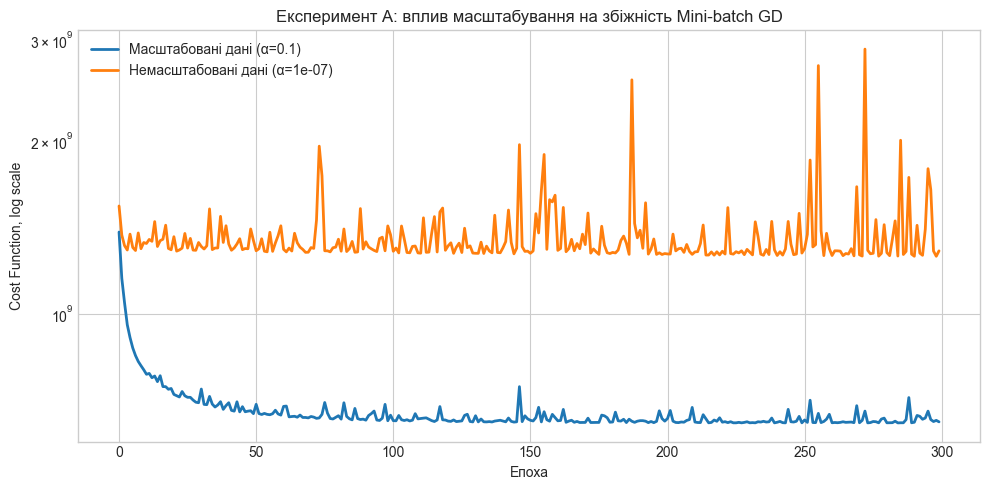

In [55]:
# За підбором вище: масштабовані дані стабільні навіть з alpha=0.1,
# а немасштабовані - лише з alpha=1e-7 (на 6 порядків менше)
alpha_scaled = 0.1
alpha_unscaled = 1e-7

model_scaled_exp, cost_scaled_exp = train_minibatch_gd(
    X_train_np, y_train_np, alpha=alpha_scaled, epochs=300, batch_size=32
)
model_unscaled_exp, cost_unscaled_exp = train_minibatch_gd(
    X_train_unscaled_np, y_train_np, alpha=alpha_unscaled, epochs=300, batch_size=32
)

print(f"\nα для масштабованих даних:   {alpha_scaled}")
print(f"α для немасштабованих даних: {alpha_unscaled} (у {alpha_scaled / alpha_unscaled:,.0f} разів менше)")
print(f"\nCost після 300 епох | Масштабовані дані:   {cost_scaled_exp[-1]:,.0f} "
      f"(R2 = {r_squared(y_train_np, model_scaled_exp.predict(X_train_np)):.4f})")
print(f"Cost після 300 епох | Немасштабовані дані: {cost_unscaled_exp[-1]:,.0f} "
      f"(R2 = {r_squared(y_train_np, model_unscaled_exp.predict(X_train_unscaled_np)):.4f})")

# Демонстрація розбіжності: застосуємо до немасштабованих даних той самий alpha, що і для масштабованих
with np.errstate(over='ignore', invalid='ignore'):
    _, cost_diverge = train_minibatch_gd(X_train_unscaled_np, y_train_np, alpha=alpha_scaled, epochs=20, batch_size=32)
print(f"\nЯкщо застосувати α={alpha_scaled} до НЕмасштабованих даних: "
      f"Cost на 20-й епосі = {cost_diverge[-1]}")

plt.figure(figsize=(10, 5))
plt.plot(cost_scaled_exp, label=f'Масштабовані дані (α={alpha_scaled})', linewidth=2)
plt.plot(cost_unscaled_exp, label=f'Немасштабовані дані (α={alpha_unscaled})', linewidth=2)
plt.yscale('log')
plt.xlabel('Епоха')
plt.ylabel('Cost Function, log scale')
plt.title('Експеримент А: вплив масштабування на збіжність Mini-batch GD')
plt.legend()
plt.tight_layout()
plt.show()


#### Висновок до Експерименту А (вплив масштабування)

Як показують результати вище, для немасштабованих даних довелося взяти Learning Rate у **мільйони разів менший**, ніж для масштабованих, і навіть при цьому за однакову кількість епох модель на немасштабованих даних досягає суттєво гіршого Cost та нижчого $R^2$. Якщо ж застосувати до немасштабованих даних Learning Rate, придатний для масштабованих ($\alpha=0.1$), Cost миттєво йде в нескінченність (розбіжність).

**Геометричне пояснення:**
> Поверхня функції втрат $J(w, b)$ для лінійної регресії — це багатовимірний параболоїд, форма якого (еліптичні лінії рівня) визначається масштабом ознак. Ознаки на кшталт `YearBuilt` (діапазон ~1870–2010) мають на кілька порядків більший масштаб, ніж бінарні OHE-стовпці (0 або 1). Через це лінії рівня Cost Function перетворюються на дуже витягнуті, «сплюснуті» еліпси: вздовж напрямку ознаки з великим масштабом поверхня дуже крута, а вздовж напрямку ознаки з малим масштабом — майже пласка.
>
> Градієнтний спуск рухається перпендикулярно до ліній рівня, тому на витягнутому еліпсі він змушений робити криві, «зигзагоподібні» кроки: маленький крок, безпечний для крутого напрямку (`YearBuilt`), є мізерно малим для плаского напрямку (бінарні ознаки), і навпаки — крок, достатній для плаского напрямку, миттєво «вибиває» алгоритм за межі параболи вздовж крутого напрямку, спричиняючи розбіжність.
>
> Після нормалізації всіх числових ознак до $[0, 1]$ (а бінарні ознаки й так лежать у цьому діапазоні) лінії рівня Cost Function стають набагато ближчими до кіл (ізотропна поверхня). Це дозволяє використовувати єдиний, значно більший Learning Rate, який однаково добре працює для всіх напрямків одразу, забезпечуючи швидку та стабільну збіжність — саме це ми й спостерігаємо на графіку вище.


## Формат здачі

Jupyter Notebook (`.ipynb`), завантажений на Github репозиторій, який містить:
* чистий, прокоментований код;
* Markdown-комірки з теоретичними поясненнями та висновками;
* результати EDA та обґрунтування вибору ознак;
* графіки навчання та статистичного аналізу;
* відповіді на теоретичні питання;
* порівняння трьох варіантів градієнтного спуску.

Код повинен бути структурований. Усі алгоритми градієнтного спуску та обчислення градієнтів для моделі лінійної регресії повинні бути реалізовані самостійно засобами `numpy`.
